In [ ]:
!rm -rf /content/drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
%ls /content/drive/MyDrive/MatchingEngine/data/features

BNB_features.csv  BTC_features.csv  ETH_features.csv  SOL_features.csv


In [ ]:
%cd /content/drive/MyDrive/MatchingEngine/data/raw

/content/drive/MyDrive/MatchingEngine/data/raw


In [6]:
!pip install pandas-ta

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.3/240.3 kB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 99.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 88.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 93.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 15.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: llvmlite
    Found existing installation: llvmlite 0.43.0
    Uninstalling llvmlite-0.43.0:
      Successfully uninstalled llvmlite-0.43.0
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninsta

In [ ]:
# --- IMPORTS ---
import os
# Set environment variable to disable Numba in pandas_ta BEFORE it's heavily used
os.environ['PANDAS_TA_NUMBA'] = '0'

import pandas as pd
import numpy as np
import pandas_ta as ta
import sys
from pathlib import Path
import traceback
from typing import Optional

# --- FIX FOR NUMBA CRASH IN PANDAS_TA ---
# Force pure-python mode
ta.cores = 0
if hasattr(ta, 'pbase'):
    ta.pbase.use_numba = False

# --- INDICATORS.PY ---
def add_basic_indicators(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    required_cols = ['Open', 'High', 'Low', 'Close', 'Volume']
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing required columns for indicators: {missing_cols}")

    # Explicitly using engine='python' for every call to bypass Numba completely
    df.ta.rsi(length=14, append=True, engine='python')
    df.ta.macd(fast=12, slow=26, signal=9, append=True, engine='python')
    df.ta.bbands(length=20, std=2, append=True, engine='python')
    df.ta.sma(length=20, append=True, engine='python')
    df.ta.ema(length=50, append=True, engine='python')
    df.ta.ema(length=200, append=True, engine='python')
    df.ta.atr(length=14, append=True, engine='python')
    return df

# --- NORMALIZATION.PY ---
def z_score_normalize(df: pd.DataFrame, columns: list) -> pd.DataFrame:
    df = df.copy()
    for col in columns:
        if col in df.columns:
            mean = df[col].mean()
            std = df[col].std()
            if std != 0:
                df[col] = (df[col] - mean) / std
    return df

def min_max_normalize(df: pd.DataFrame, columns: list) -> pd.DataFrame:
    df = df.copy()
    for col in columns:
        if col in df.columns:
            min_val = df[col].min()
            max_val = df[col].max()
            if max_val != min_val:
                df[col] = (df[col] - min_val) / (max_val - min_val)
    return df

def calculate_log_returns(df: pd.DataFrame, column: str = 'Close') -> pd.DataFrame:
    df = df.copy()
    if column in df.columns:
        df[f'{column}_log_return'] = np.log(df[column] / df[column].shift(1))
    return df

def calculate_pct_returns(df: pd.DataFrame, column: str = 'Close') -> pd.DataFrame:
    df = df.copy()
    if column in df.columns:
        df[f'{column}_pct_return'] = df[column].pct_change()
    return df

# --- ENGINEERING.PY ---
class DataPipeline:
    def __init__(self, raw_data_dir: str, processed_data_dir: str, features_dir: str):
        self.raw_data_dir = Path(raw_data_dir)
        self.processed_data_dir = Path(processed_data_dir)
        self.features_dir = Path(features_dir)

        self.raw_data_dir.mkdir(parents=True, exist_ok=True)
        self.processed_data_dir.mkdir(parents=True, exist_ok=True)
        self.features_dir.mkdir(parents=True, exist_ok=True)

    def load_data(self, filename: str) -> pd.DataFrame:
        file_path = self.raw_data_dir / filename
        if not file_path.exists():
            raise FileNotFoundError(f"Data file not found: {file_path}")

        if filename.endswith('.csv'):
            return pd.read_csv(file_path)
        else:
            return pd.read_parquet(file_path)

    def clean_data(self, df: pd.DataFrame) -> pd.DataFrame:
        col_map = {col: col.capitalize() for col in df.columns if col.lower() in ['open', 'high', 'low', 'close', 'volume']}
        df = df.rename(columns=col_map)

        time_cols = [col for col in df.columns if 'time' in col.lower() or 'date' in col.lower()]
        if time_cols:
            time_col = time_cols[0]
            df[time_col] = pd.to_datetime(df[time_col])
            df = df.sort_values(by=time_col).reset_index(drop=True)
        return df

    def feature_engineering(self, df: pd.DataFrame) -> pd.DataFrame:
        df = add_basic_indicators(df)
        df = calculate_log_returns(df, column='Close')
        return df

    def normalize_data(self, df: pd.DataFrame) -> pd.DataFrame:
        exclude_cols = [col for col in df.columns if 'time' in col.lower() or 'date' in col.lower()]
        exclude_cols.extend(['Open', 'High', 'Low', 'Close'])
        normalize_cols = [col for col in df.columns if col not in exclude_cols and pd.api.types.is_numeric_dtype(df[col])]
        df = z_score_normalize(df, normalize_cols)
        return df

    def run(self, filename: str) -> Optional[pd.DataFrame]:
        try:
            print(f"\n--- Starting pipeline for {filename} ---")
            df = self.load_data(filename)

            df = self.clean_data(df)
            df = df.ffill().bfill()

            processed_path = self.processed_data_dir / filename
            self.processed_data_dir.mkdir(parents=True, exist_ok=True)
            if filename.endswith('.csv'):
                df.to_csv(processed_path, index=False)
            else:
                df.to_parquet(processed_path, index=False)

            print("  -> Running feature engineering (calculating indicators)...")
            df = self.feature_engineering(df)
            df = df.dropna().reset_index(drop=True)

            df = self.normalize_data(df)

            features_name = filename.replace('.csv', '_features.csv').replace('.parquet', '_features.parquet')
            features_path = self.features_dir / features_name
            self.features_dir.mkdir(parents=True, exist_ok=True)

            if features_path.suffix == '.csv':
                df.to_csv(features_path, index=False)
            else:
                df.to_parquet(features_path, index=False)

            print(f"  -> Success! Final features saved to {features_path.name}")
            return df

        except Exception as e:
            print(f"\n!!! Error processing {filename} !!!")
            traceback.print_exc()
            return None

# --- RUN EXECUTION ---
if __name__ == '__main__':
    base_dir = Path('/content/drive/MyDrive/MatchingEngine/data')

    pipeline = DataPipeline(
        raw_data_dir=str(base_dir / 'raw'),
        processed_data_dir=str(base_dir / 'processed'),
        features_dir=str(base_dir / 'features')
    )

    print(f'Pipeline initialized. Base dir: {base_dir}')

    raw_dir = base_dir / 'raw'
    if raw_dir.exists():
        csv_files = [f.name for f in raw_dir.iterdir() if f.is_file() and f.suffix == '.csv']
        if not csv_files:
            print(f'No CSV files found in {raw_dir}')
        for file in csv_files:
            pipeline.run(file)
    else:
        print(f'Directory {raw_dir} does not exist.')

Pipeline initialized. Base dir: /content/drive/MyDrive/MatchingEngine/data

--- Starting pipeline for ETH.csv ---
  -> Running feature engineering (calculating indicators)...
  -> Success! Final features saved to ETH_features.csv

--- Starting pipeline for SOL.csv ---
  -> Running feature engineering (calculating indicators)...
  -> Success! Final features saved to SOL_features.csv

--- Starting pipeline for BTC.csv ---
  -> Running feature engineering (calculating indicators)...
  -> Success! Final features saved to BTC_features.csv

--- Starting pipeline for BNB.csv ---
  -> Running feature engineering (calculating indicators)...
  -> Success! Final features saved to BNB_features.csv


In [2]:
!pip install stable-baselines3[extra] pandas gymnasium numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 114.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.6/187.6 kB 19.4 MB/s eta 0:00:00


In [2]:
# --- STEP 1: INSTALL DEPENDENCIES (Run this in a separate cell first if needed) ---
# !pip install stable-baselines3[extra] pandas gymnasium numpy

# --- STEP 2: MOUNT GOOGLE DRIVE (Run this in a separate cell first if needed) ---
# from google.colab import drive
# drive.mount('/content/drive')

# --- COMBINED RL TRAINING SCRIPT ---
import os
import copy
from enum import IntEnum
from typing import Optional
from pathlib import Path

import numpy as np
import pandas as pd
import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.monitor import Monitor

# ==========================================
# 1. ACTIONS
# ==========================================
class TradeAction(IntEnum):
    HOLD = 0
    BUY = 1
    SELL = 2

def get_action_space() -> spaces.Discrete:
    """Returns a Discrete action space for Hold (0), Buy (1), Sell (2)."""
    return spaces.Discrete(3)

# ==========================================
# 2. PORTFOLIO
# ==========================================
class Portfolio:
    def __init__(self, initial_cash: float = 10000.0):
        self.initial_cash = initial_cash
        self.cash = initial_cash
        self.inventory = 0.0
        self.average_price = 0.0
        self.realized_pnl = 0.0
        self.unrealized_pnl = 0.0

    def reset(self):
        self.cash = self.initial_cash
        self.inventory = 0.0
        self.average_price = 0.0
        self.realized_pnl = 0.0
        self.unrealized_pnl = 0.0

    def update_from_trade(self, action_type: str, trade_size: float, price: float, cost: float):
        self.cash -= cost
        self.realized_pnl -= cost

        if action_type == 'BUY':
            cost_of_purchase = trade_size * price
            self.cash -= cost_of_purchase

            total_value = (self.inventory * self.average_price) + cost_of_purchase
            self.inventory += trade_size
            self.average_price = total_value / self.inventory

        elif action_type == 'SELL':
            revenue = trade_size * price
            self.cash += revenue

            trade_pnl = (price - self.average_price) * trade_size
            self.realized_pnl += trade_pnl

            self.inventory -= trade_size

            if self.inventory <= 0:
                self.inventory = 0.0
                self.average_price = 0.0

    def update_unrealized_pnl(self, current_price: float):
        if self.inventory > 0:
            self.unrealized_pnl = (current_price - self.average_price) * self.inventory
        else:
            self.unrealized_pnl = 0.0

    def get_portfolio_value(self, current_price: float) -> float:
        return self.cash + (self.inventory * current_price)

    def get_state_array(self, current_price: float) -> np.ndarray:
        self.update_unrealized_pnl(current_price)

        norm_cash = self.cash / self.initial_cash
        max_possible_inventory = self.initial_cash / current_price if current_price > 0 else 1.0
        norm_inventory = self.inventory / max_possible_inventory
        norm_unrealized = self.unrealized_pnl / self.initial_cash
        norm_realized = self.realized_pnl / self.initial_cash
        norm_total = self.get_portfolio_value(current_price) / self.initial_cash

        return np.array([
            norm_cash, norm_inventory, norm_unrealized, norm_realized, norm_total
        ], dtype=np.float32)

# ==========================================
# 3. SIMULATOR
# ==========================================
class Simulator:
    def __init__(self, commission_rate: float = 0.001, slippage_pct: float = 0.0005, trade_fraction: float = 0.2):
        self.commission_rate = commission_rate
        self.slippage_pct = slippage_pct
        self.trade_fraction = trade_fraction

    def execute_trade(self, action: int, current_price: float, portfolio: Portfolio):
        trade_costs = 0.0

        if action == TradeAction.HOLD:
            return trade_costs

        elif action == TradeAction.BUY:
            max_size_possible = portfolio.cash / (current_price * (1 + self.commission_rate + self.slippage_pct))
            trade_size = max_size_possible * self.trade_fraction

            if trade_size > 0.00001:
                fill_price = current_price * (1 + self.slippage_pct)
                commission = (trade_size * fill_price) * self.commission_rate
                trade_costs = commission + ((fill_price - current_price) * trade_size)
                portfolio.update_from_trade('BUY', trade_size, fill_price, commission)

        elif action == TradeAction.SELL:
            trade_size = portfolio.inventory * self.trade_fraction

            if trade_size > 0.00001:
                fill_price = current_price * (1 - self.slippage_pct)
                commission = (trade_size * fill_price) * self.commission_rate
                trade_costs = commission + ((current_price - fill_price) * trade_size)
                portfolio.update_from_trade('SELL', trade_size, fill_price, commission)

        return trade_costs

# ==========================================
# 4. REWARD CALCULATOR
# ==========================================
class RewardCalculator:
    def __init__(self, inventory_penalty_weight: float = 0.0, drawdown_penalty_weight: float = 0.0, step_penalty: float = 0.0001):
        self.inventory_penalty_weight = inventory_penalty_weight
        self.drawdown_penalty_weight = drawdown_penalty_weight
        self.step_penalty = step_penalty
        self.peak_portfolio_value = 0.0
        self.initial_value = 1.0

    def reset(self, initial_value: float):
        self.peak_portfolio_value = initial_value
        self.initial_value = initial_value if initial_value > 0 else 1.0

    def calculate(self, portfolio_before: Portfolio, portfolio_after: Portfolio, trade_costs: float, current_price: float) -> float:
        val_before = portfolio_before.get_portfolio_value(current_price)
        val_after = portfolio_after.get_portfolio_value(current_price)

        delta_pnl_pct = (val_after - val_before) / self.initial_value

        inventory_val = portfolio_after.inventory * current_price
        inventory_penalty = self.inventory_penalty_weight * (inventory_val / self.initial_value)

        self.peak_portfolio_value = max(self.peak_portfolio_value, val_after)
        drawdown = max(0, self.peak_portfolio_value - val_after)
        drawdown_penalty = self.drawdown_penalty_weight * (drawdown / self.initial_value)

        reward = delta_pnl_pct - inventory_penalty - drawdown_penalty - self.step_penalty
        return reward

# ==========================================
# 5. OBSERVATION BUILDER
# ==========================================
class ObservationBuilder:
    def __init__(self, feature_columns: list):
        self.feature_columns = feature_columns
        self.num_market_features = len(feature_columns)
        self.num_portfolio_features = 5

    def get_observation_space(self) -> spaces.Box:
        total_features = self.num_market_features + self.num_portfolio_features
        return spaces.Box(low=-np.inf, high=np.inf, shape=(total_features,), dtype=np.float32)

    def build_observation(self, market_data_row: np.ndarray, portfolio: Portfolio, current_price: float) -> np.ndarray:
        market_obs = np.array(market_data_row, dtype=np.float32)
        portfolio_obs = portfolio.get_state_array(current_price)
        full_obs = np.concatenate([market_obs, portfolio_obs])
        return full_obs

# ==========================================
# 6. GYM ENVIRONMENT
# ==========================================
class HistoricalMarketEnv(gym.Env):
    metadata = {"render_modes": ["human"]}

    def __init__(self, data_path: Optional[str] = None, data_df: Optional[pd.DataFrame] = None, initial_cash: float = 10000.0, max_steps: int = 500, trade_fraction: float = 0.2):
        super().__init__()

        if data_df is not None:
            self.df = data_df.copy()
            self.df.reset_index(drop=True, inplace=True)
        elif data_path is not None:
            self.df = pd.read_csv(data_path)
        else:
            raise ValueError("Must provide either data_path or data_df")

        if 'Close' not in self.df.columns:
            raise ValueError("Data must contain a 'Close' column for pricing.")

        self.prices = self.df['Close'].values

        self.feature_columns = ['Close', 'Volume']
        self.features_array = self.df[self.feature_columns].values

        self.max_steps = max_steps
        self.current_step_idx = 0
        self.start_index = 0
        self.max_idx = len(self.df) - 1

        self.portfolio = Portfolio(initial_cash=initial_cash)
        self.simulator = Simulator(trade_fraction=trade_fraction)
        self.reward_calc = RewardCalculator()
        self.obs_builder = ObservationBuilder(self.feature_columns)

        self.action_space = get_action_space()
        self.observation_space = self.obs_builder.get_observation_space()

    def reset(self, seed: Optional[int] = None, options: Optional[dict] = None):
        super().reset(seed=seed)

        max_possible_start = max(0, self.max_idx - self.max_steps - 1)
        if max_possible_start > 0:
            self.start_index = self.np_random.integers(0, max_possible_start)
        else:
            self.start_index = 0

        self.current_step_idx = self.start_index
        self.portfolio.reset()

        current_price = self.prices[self.current_step_idx]
        initial_val = self.portfolio.get_portfolio_value(current_price)
        self.reward_calc.reset(initial_val)

        obs = self.obs_builder.build_observation(self.features_array[self.current_step_idx], self.portfolio, current_price)
        return obs, self._get_info()

    def step(self, action: int):
        current_price = self.prices[self.current_step_idx]
        portfolio_before = copy.deepcopy(self.portfolio)

        trade_costs = self.simulator.execute_trade(action, current_price, self.portfolio)
        self.current_step_idx += 1
        next_price = self.prices[self.current_step_idx]

        reward = self.reward_calc.calculate(portfolio_before, self.portfolio, trade_costs, next_price)
        obs = self.obs_builder.build_observation(self.features_array[self.current_step_idx], self.portfolio, next_price)

        terminated = (self.portfolio.cash <= 0 and self.portfolio.inventory <= 0)
        truncated = ((self.current_step_idx - self.start_index) >= self.max_steps) or (self.current_step_idx >= self.max_idx)

        return obs, reward, terminated, truncated, self._get_info()

    def _get_info(self):
        return {
            "step": self.current_step_idx,
            "cash": self.portfolio.cash,
            "inventory": self.portfolio.inventory,
            "realized_pnl": self.portfolio.realized_pnl,
            "unrealized_pnl": self.portfolio.unrealized_pnl,
            "total_value": self.portfolio.get_portfolio_value(self.prices[self.current_step_idx])
        }

# ==========================================
# 7. TRAINING FUNCTION
# ==========================================
def train_agent(data_path: str, model_save_path: str, total_timesteps: int = 100000):
    print(f"Loading data from {data_path}...")
    df = pd.read_csv(data_path)

    # 80/20 Train/Test Split
    split_idx = int(len(df) * 0.8)
    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()
    print(f"Train data size: {len(train_df)}, Test data size: {len(test_df)}")

    # We use a Monitor wrapper to log episode rewards and lengths
    def make_env():
        env = HistoricalMarketEnv(data_df=train_df, initial_cash=10000.0, max_steps=500, trade_fraction=0.2)
        return Monitor(env)

    vec_env = DummyVecEnv([make_env])

    print("Initializing PPO model...")
    model = PPO(
        "MlpPolicy",
        vec_env,
        verbose=1,
        ent_coef=0.05,
        tensorboard_log="./logs/ppo_market_maker/"
    )

    print(f"Starting training for {total_timesteps} timesteps...")
    model.learn(total_timesteps=total_timesteps)

    os.makedirs(Path(model_save_path).parent, exist_ok=True)
    model.save(model_save_path)
    print(f"Model saved to {model_save_path}")

    return train_df, test_df

# ==========================================
# 8. EXECUTION SCRIPT
# ==========================================
if __name__ == "__main__":
    # >>> CHANGE THESE PATHS TO MATCH YOUR GOOGLE DRIVE <<<
    # Note: Ensure the BTC_features.csv actually exists at this path!
    data_file = "/content/drive/MyDrive/MatchingEngine/data/features/BTC_features.csv"

    # The folder models/ will be created in your Drive if it doesn't exist
    model_save_file = "/content/drive/MyDrive/MatchingEngine/models/ppo_trading_model"

    train_agent(data_file, model_save_file, total_timesteps=500000)


Loading data from /content/drive/MyDrive/MatchingEngine/data/features/BTC_features.csv...
Train data size: 236574, Test data size: 59144
Initializing PPO model...
Using cuda device


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Starting training for 500000 timesteps...
Logging to ./logs/ppo_market_maker/PPO_1


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Streaming output truncated to the last 5000 lines.
-----------------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 500          |
|    ep_rew_mean          | -0.0937      |
| time/                   |              |
|    fps                  | 428          |
|    iterations           | 8            |
|    time_elapsed         | 38           |
|    total_timesteps      | 16384        |
| train/                  |              |
|    approx_kl            | 0.0041299528 |
|    clip_fraction        | 0.0177       |
|    clip_range           | 0.2          |
|    entropy_loss         | -1           |
|    explained_variance   | 5.96e-08     |
|    learning_rate        | 0.0003       |
|    loss                 | -0.0617      |
|    n_updates            | 70           |
|    policy_gradient_loss | -0.00214     |
|    value_loss           | 2.36e-05     |
------------------------------------------
----

Loading data from /content/drive/MyDrive/MatchingEngine/data/features/BTC_features.csv for backtesting...
Loading trained brain from /content/drive/MyDrive/MatchingEngine/models/ppo_trading_model...
Starting unseen data backtest simulation...


/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Backtest complete. Ran for 59143 steps.

========= BACKTEST METRICS =========
Total PnL: 0.00
Total Return (%): 0.00
Sharpe Ratio: 0.00
Max Drawdown (%): 0.00
Total Trades: 59143
Buys: 0
Sells: 59143


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Plot saved to Drive at /content/drive/MyDrive/MatchingEngine/evaluation/backtest_results.png


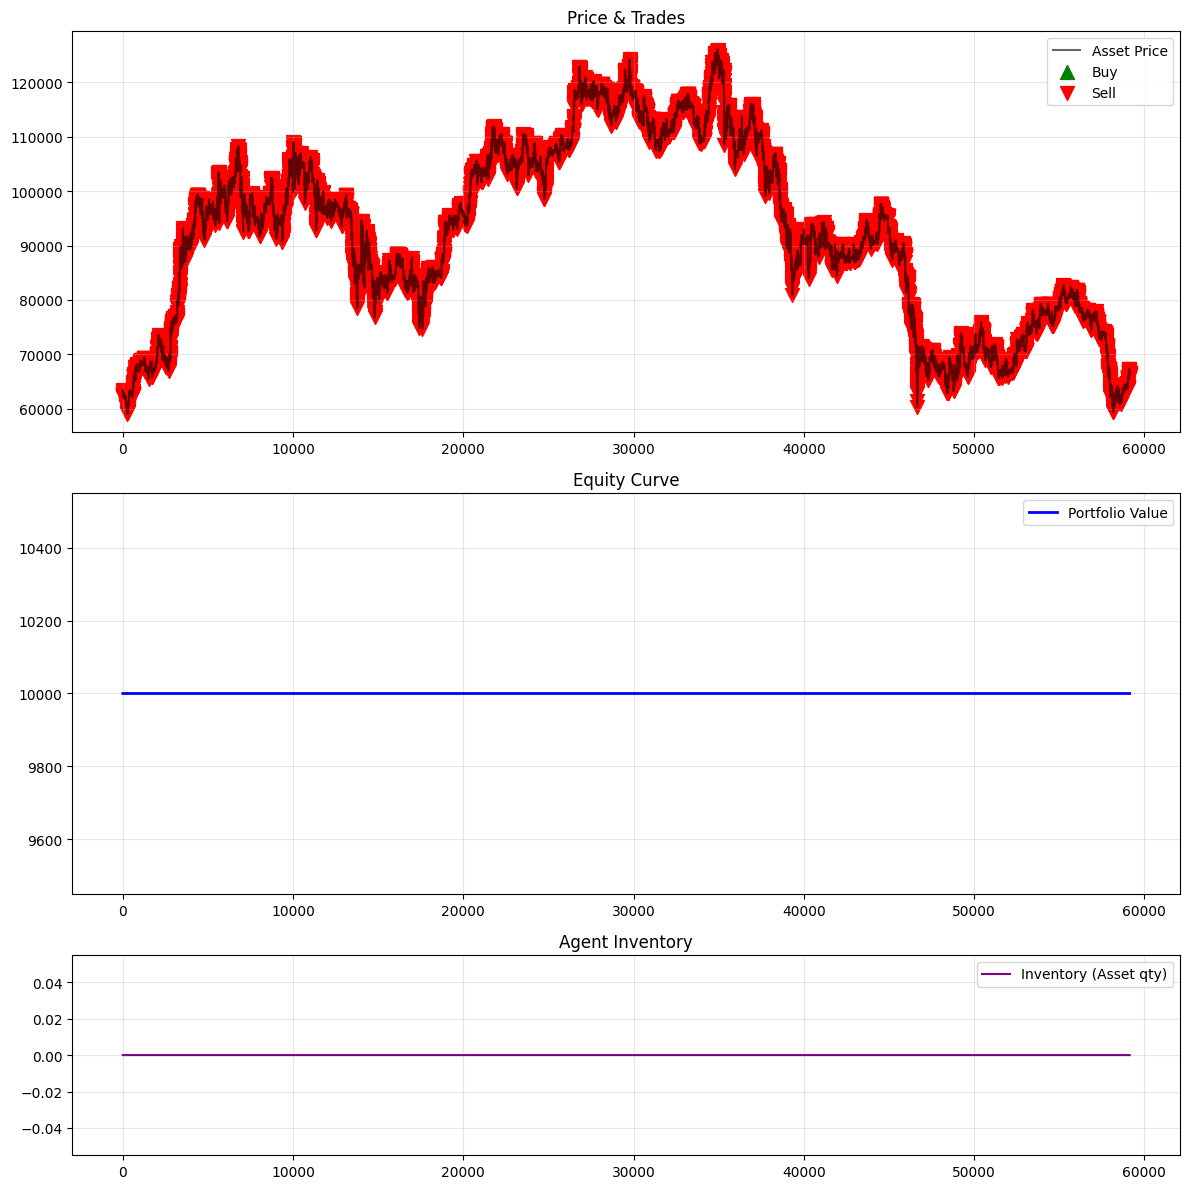

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
from stable_baselines3 import PPO

# --- 1. METRICS CALCULATOR ---
def calculate_metrics(portfolio_values: list, trades: list, initial_cash: float):
    if len(portfolio_values) < 2: return {}
    final_value = portfolio_values[-1]
    total_pnl = final_value - initial_cash
    total_return_pct = (total_pnl / initial_cash) * 100

    values_array = np.array(portfolio_values)
    step_returns = np.diff(values_array) / values_array[:-1]

    mean_return = np.mean(step_returns)
    std_return = np.std(step_returns)
    sharpe_ratio = 0.0
    if std_return > 0:
        sharpe_ratio = (mean_return / std_return) * np.sqrt(len(step_returns))

    peak = values_array[0]
    max_drawdown = 0.0
    for val in values_array:
        if val > peak: peak = val
        drawdown = (peak - val) / peak
        if drawdown > max_drawdown: max_drawdown = drawdown

    total_trades = len(trades)
    buy_count = sum(1 for t in trades if t['action'] == 'BUY')
    sell_count = sum(1 for t in trades if t['action'] == 'SELL')

    return {
        "Total PnL": total_pnl,
        "Total Return (%)": total_return_pct,
        "Sharpe Ratio": sharpe_ratio,
        "Max Drawdown (%)": max_drawdown * 100,
        "Total Trades": total_trades,
        "Buys": buy_count,
        "Sells": sell_count
    }

# --- 2. PLOTTING ---
def plot_backtest_results(df: pd.DataFrame, save_path: str):
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), gridspec_kw={'height_ratios': [2, 2, 1]})

    ax1.plot(df['step'], df['price'], label='Asset Price', color='black', alpha=0.6)
    buys = df[df['action'] == 'BUY']
    sells = df[df['action'] == 'SELL']

    ax1.scatter(buys['step'], buys['price'], marker='^', color='green', s=100, label='Buy')
    ax1.scatter(sells['step'], sells['price'], marker='v', color='red', s=100, label='Sell')
    ax1.set_title("Price & Trades")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(df['step'], df['portfolio_value'], label='Portfolio Value', color='blue', linewidth=2)
    ax2.set_title("Equity Curve")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    ax3.plot(df['step'], df['inventory'], label='Inventory (Asset qty)', color='purple', drawstyle='steps-post')
    ax3.set_title("Agent Inventory")
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path)
    print(f"Plot saved to Drive at {save_path}")
    plt.show()  # Display inline in Colab!

# --- 3. BACKTEST RUNNER ---
def run_backtest(model_path: str, data_path: str):
    print(f"Loading data from {data_path} for backtesting...")
    df = pd.read_csv(data_path)

    # We use the LAST 20% of the data (the unseen test set)
    split_idx = int(len(df) * 0.8)
    test_df = df.iloc[split_idx:].copy()

    # We rely on HistoricalMarketEnv and TradeAction from the training script cell!
    env = HistoricalMarketEnv(data_df=test_df, initial_cash=10000.0, max_steps=len(test_df), trade_fraction=0.2)
    env.start_index = 0

    print(f"Loading trained brain from {model_path}...")
    try:
        model = PPO.load(model_path)
    except Exception as e:
        print(f"Failed to load model: {e}")
        return

    obs, info = env.reset()
    env.current_step_idx = 0

    history = []
    trades = []
    portfolio_values = []

    print("Starting unseen data backtest simulation...")
    done = False
    step_count = 0

    while not done:
        # deterministic=True ensures the agent uses its strict rules without random exploration
        action, _states = model.predict(obs, deterministic=True)
        action_scalar = int(action) if hasattr(action, '__int__') else int(action.item())
        action_name = TradeAction(action_scalar).name

        obs, reward, terminated, truncated, info = env.step(action_scalar)

        step_data = {
            'step': step_count,
            'price': env.prices[env.current_step_idx - 1],
            'portfolio_value': info['total_value'],
            'inventory': info['inventory'],
            'action': action_name,
            'reward': reward
        }
        history.append(step_data)
        portfolio_values.append(info['total_value'])

        if action_name in ['BUY', 'SELL']:
            trades.append(step_data)

        step_count += 1
        done = terminated or truncated

    print(f"Backtest complete. Ran for {step_count} steps.")
    history_df = pd.DataFrame(history)

    metrics = calculate_metrics(portfolio_values, trades, initial_cash=10000.0)
    print("\n========= BACKTEST METRICS =========")
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"{k}: {v:.2f}")
        else:
            print(f"{k}: {v}")
    print("====================================")

    save_path = "/content/drive/MyDrive/MatchingEngine/evaluation/backtest_results.png"
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plot_backtest_results(history_df, save_path=save_path)

# --- EXECUTE ---
data_file = "/content/drive/MyDrive/MatchingEngine/data/features/BTC_features.csv"
model_file = "/content/drive/MyDrive/MatchingEngine/models/ppo_trading_model"

run_backtest(model_file, data_file)
